# Multivariable linear regrression


In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score 

In [11]:
california=datasets.fetch_california_housing()
x=california.data
y=california.target
# print(x)
# print(y)
print(x.shape)
print(y.shape)
print(california.feature_names)

(20640, 8)
(20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=11)
model=LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
print("Coefficients (m1,m2,m3...mn):\n", model.coef_)
print("Intercept(b0,b1,b2,b3...bn):\n", model.intercept_)


Coefficients (m1,m2,m3...mn):
 [ 4.33481147e-01  9.13203774e-03 -1.00206297e-01  6.11611814e-01
 -5.80927065e-06 -3.41460825e-03 -4.26281098e-01 -4.41029824e-01]
Intercept(b0,b1,b2,b3...bn):
 -37.52785391522627


In [5]:
y_pred_test = model.predict(x_test)
y_pred_train=model.predict(x_train)


In [14]:

print("MSE_test:", mean_squared_error(y_test, y_pred_test))
print("MSE_train:", mean_squared_error(y_train, y_pred_train))

print("r2 value_test:", r2_score(y_test, y_pred_test))
print("r2 value_train:", r2_score(y_train, y_pred_train))




MSE_test: 0.5304460892018628
MSE_train: 0.5229180518054783
r2 value_test: 0.605787292569561
r2 value_train: 0.6061334059992144


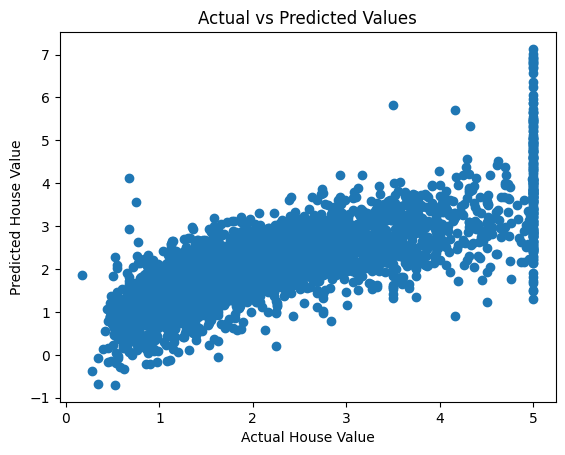

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# Make sure your classifier object is trained and available in the environment

def plot_decision_boundary(X_set, y_set, classifier, title):

    age_step = 1
    salary_step = 1000 
    
    # Setup the canvas
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = age_step),np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = salary_step))
    
    # Predict over the meshgrid to create the background color map
    Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(X1, X2, Z, alpha = 0.5, cmap = ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    color = ListedColormap(('red', 'green'))(i), label = f'Purchased: {bool(j)}',
                    edgecolor='white', s=60, alpha=0.9)

    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()
    plt.show()

plot_decision_boundary(x_train, y_train, classifier, 'Logistic Regression (Training Set Results)')


NameError: name 'X_train' is not defined

In [ ]:
plot_decision_boundary(X_test, y_pred, classifier, 'Logistic Regression (Testing Set Results)')
